# **EXPERIMENT-9** -Mushrooms Dataset

In [ ]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Step 2: Load dataset
from google.colab import drive
drive.mount('/content/drive')
df=pd.read_csv('/content/drive/MyDrive/Datasets/mushrooms.csv')
print("shape:\n",df.shape)
print("\nFirst 2 rows:\n",df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
shape:
 (8124, 23)

First 2 rows:
   class cap-shape cap-surface cap-color bruises odor gill-attachment  \
0     p         x           s         n       t    p               f   
1     e         x           s         y       t    a               f   
2     e         b           s         w       t    l               f   

  gill-spacing gill-size gill-color  ... stalk-surface-below-ring  \
0            c         n          k  ...                        s   
1            c         b          k  ...                        s   
2            c         b          n  ...                        s   

  stalk-color-above-ring stalk-color-below-ring veil-type veil-color  \
0                      w                      w         p          w   
1                      w                      w         p          w   
2                      w                      w       

In [ ]:
# Step 3: Check missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


In [ ]:
# Step 4: Encode categorical features
encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
print("\nEncoded Data Sample:\n", df.head())


Encoded Data Sample:
    class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      1          5            2          4        1     6                1   
1      0          5            2          9        1     0                1   
2      0          0            2          8        1     3                1   
3      1          5            3          8        1     6                1   
4      0          5            2          3        0     5                1   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
0             0          1           4  ...                         2   
1             0          0           4  ...                         2   
2             0          0           5  ...                         2   
3             0          1           5  ...                         2   
4             1          0           4  ...                         2   

   stalk-color-above-ring  stalk-color-below-ring  veil-type  v

In [ ]:
# Step 5: Split features and target
X = df.drop('class', axis=1)
y = df['class']

In [ ]:
# Step 6: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,stratify=y,random_state=42)
print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (6499, 22)
Testing shape: (1625, 22)


In [ ]:
# Step 7: Build Random Forest Model
rf = RandomForestClassifier(
    n_estimators=200,     # number of trees
    max_depth=None,       # grow trees fully
    max_features='sqrt',  # random subset of features
    bootstrap=True,       # enable bootstrap sampling
    oob_score=True,       # use out-of-bag validation
    random_state=42,
    n_jobs=-1
)
# Train model
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, oob_score=True,
                       random_state=42)

In [ ]:
# Step 8: OOB Score
print("OOB Score:", rf.oob_score_)

OOB Score: 1.0


In [ ]:
# Step 9: Predictions
y_pred = rf.predict(X_test)
print("\nFirst 20 Predicted Values:\n", y_pred[:20])
print("\nFirst 20 Actual Values:\n", y_test[:20].values)


First 20 Predicted Values:
 [1 1 0 1 1 0 0 0 0 1 1 1 0 0 0 1 1 0 0 1]

First 20 Actual Values:
 [1 1 0 1 1 0 0 0 0 1 1 1 0 0 0 1 1 0 0 1]


In [ ]:
# Step 10: Model Evaluation
print("\nTest Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Test Accuracy: 1.0

Confusion Matrix:
 [[842   0]
 [  0 783]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



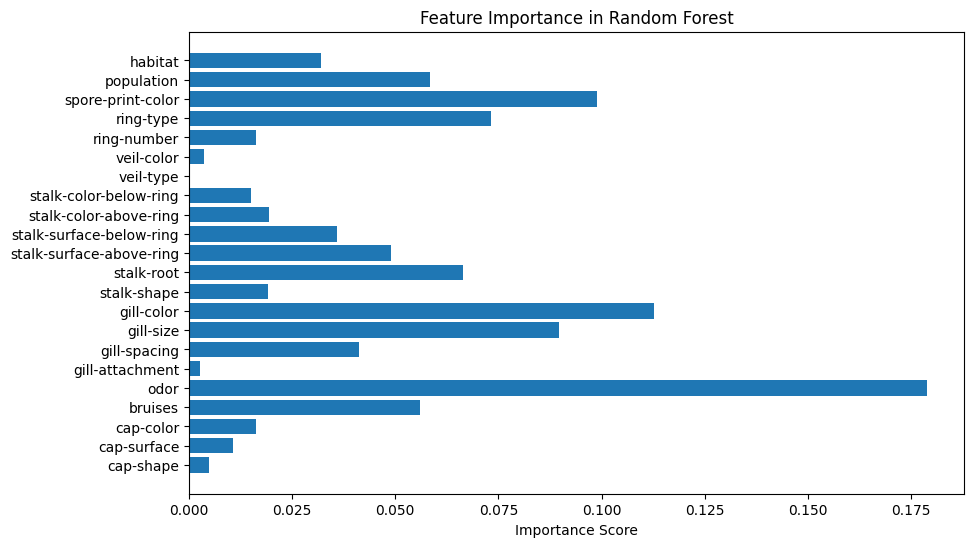

In [ ]:
# Step 11: Feature Importance
importances = rf.feature_importances_
features = X.columns
plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.xlabel("Importance Score")
plt.title("Feature Importance in Random Forest")
plt.show()
